In [1]:
import sys

print("Google Colab is working.")
print("Python version:", sys.version)

Google Colab is working.
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


# Time Series Analysis of Air Raid Alerts in Ukraine

## Project goal

This project explores temporal patterns in air raid alerts in Ukraine using Python and time series analysis. The research question is: How did the weekly frequency and cumulative duration of oblast-level air-raid alerts change in Ukraine, and which oblasts accumulated the greatest alert burden?


#**Data source and analytical scope**

The analysis uses the public official_data_en.csv file from the Ukrainian Air Raid Sirens Dataset repository. The dataset contains event-level records with the geographic level, oblast name, alert start time, alert end time, and source. Timestamps are originally stored in UTC and were converted to the Europe/Kyiv timezone for the analysis.

The initial audit showed that the file contains records reported at oblast, raion, and hromada levels. These levels cannot be combined directly because overlapping notifications may produce double counting. The audit also identified a substantial transition from oblast-level to raion-level reporting beginning in August 2025.

To preserve geographic comparability, the final analysis was restricted to oblast-level records from 15 March 2022 through 31 July 2025.

DATASET DIMENSIONS
Rows: 273,584
Columns: 7

COLUMNS
['oblast', 'raion', 'hromada', 'level', 'started_at', 'finished_at', 'source']

DATE RANGE
Earliest start: 2022-03-15 16:10:34+00:00
Latest start:   2026-06-24 23:59:12+00:00

GEOGRAPHIC LEVEL COUNTS


,level,record_count
0,oblast,130055
1,raion,108181
2,hromada,35348


BASIC QUALITY CHECKS


,count
missing/unparsed started_at,0
missing/unparsed finished_at,0
exact duplicate rows,113845
negative durations,0
zero durations,4
missing durations,0


MONTHLY RECORD COUNTS BY GEOGRAPHIC LEVEL


level,hromada,oblast,raion
month,,,
2022-03-01,812,1992,508
2022-04-01,778,3502,632
2022-05-01,780,3424,254
2022-06-01,746,2860,206
2022-07-01,666,2442,80
2022-08-01,692,3158,26
2022-09-01,638,2970,52
2022-10-01,450,3076,4
2022-11-01,218,1856,2


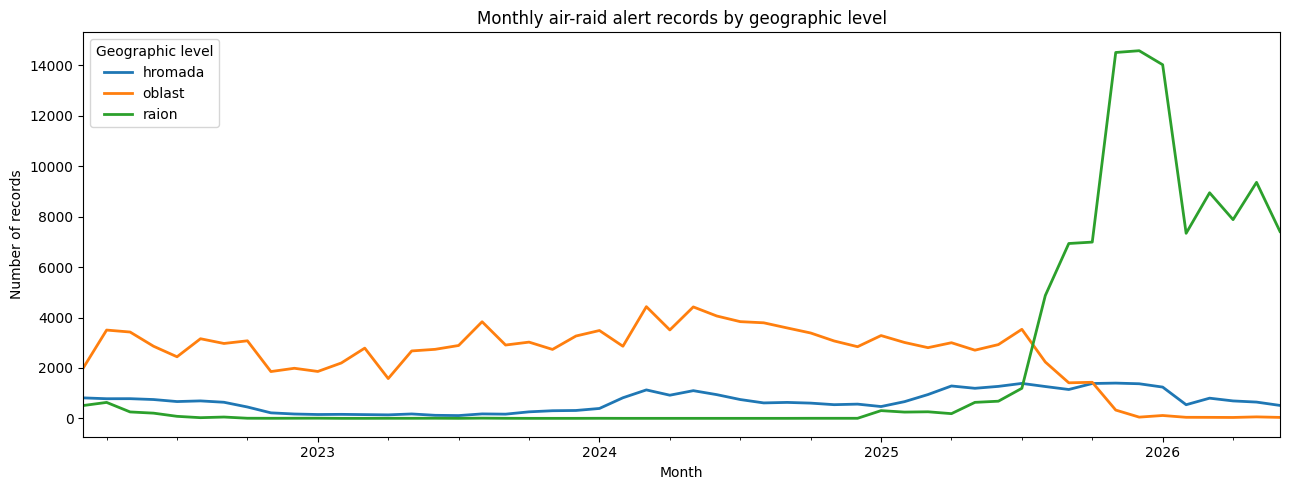

In [2]:
# Minimal audit of official_data_en.csv

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "Vadimkin/ukrainian-air-raid-sirens-dataset/"
    "main/datasets/official_data_en.csv"
)

# 1. Load data
df = pd.read_csv(DATA_URL, low_memory=False)

print("DATASET DIMENSIONS")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()

print("COLUMNS")
print(df.columns.tolist())
print()

# Confirm that essential columns exist
required_columns = ["level", "started_at", "finished_at"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# 2. Parse timestamps and calculate duration
df["started_at"] = pd.to_datetime(
    df["started_at"],
    errors="coerce",
    utc=True
)

df["finished_at"] = pd.to_datetime(
    df["finished_at"],
    errors="coerce",
    utc=True
)

df["duration_hours"] = (
    df["finished_at"] - df["started_at"]
).dt.total_seconds() / 3600

# 3. Basic audit
print("DATE RANGE")
print("Earliest start:", df["started_at"].min())
print("Latest start:  ", df["started_at"].max())
print()

print("GEOGRAPHIC LEVEL COUNTS")
display(
    df["level"]
    .value_counts(dropna=False)
    .rename_axis("level")
    .reset_index(name="record_count")
)

audit_summary = pd.Series(
    {
        "missing/unparsed started_at":
            int(df["started_at"].isna().sum()),

        "missing/unparsed finished_at":
            int(df["finished_at"].isna().sum()),

        "exact duplicate rows":
            int(df.duplicated().sum()),

        "negative durations":
            int((df["duration_hours"] < 0).sum()),

        "zero durations":
            int((df["duration_hours"] == 0).sum()),

        "missing durations":
            int(df["duration_hours"].isna().sum()),
    },
    name="count"
)

print("BASIC QUALITY CHECKS")
display(audit_summary.to_frame())

# 4. Monthly record counts by geographic level
valid_dates = df.dropna(subset=["started_at"]).copy()

valid_dates["month"] = (
    valid_dates["started_at"]
    .dt.tz_convert(None)
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_level_counts = (
    valid_dates
    .groupby(["month", "level"], dropna=False)
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print("MONTHLY RECORD COUNTS BY GEOGRAPHIC LEVEL")
display(monthly_level_counts)

# 5. Simple diagnostic plot
ax = monthly_level_counts.plot(
    figsize=(13, 5),
    linewidth=2
)

ax.set_title("Monthly air-raid alert records by geographic level")
ax.set_xlabel("Month")
ax.set_ylabel("Number of records")
ax.legend(title="Geographic level")

plt.tight_layout()
plt.show()

In [3]:
# Final micro-audit: duplicates and zero-duration records

# Count duplicates that would be removed
duplicate_rows = df[df.duplicated(keep="first")]

print("DUPLICATE ROWS REMOVED BY GEOGRAPHIC LEVEL")
display(
    duplicate_rows["level"]
    .value_counts(dropna=False)
    .rename_axis("level")
    .reset_index(name="duplicates_removed")
)

# Remove exact duplicates
df_clean = df.drop_duplicates().copy()

print(f"Rows before deduplication: {len(df):,}")
print(f"Rows after deduplication:  {len(df_clean):,}")
print(f"Rows removed:              {len(df) - len(df_clean):,}")
print()

# Inspect the four zero-duration events
print("ZERO-DURATION RECORDS AFTER DEDUPLICATION")
display(
    df_clean.loc[
        df_clean["duration_hours"].eq(0),
        ["oblast", "raion", "hromada", "level",
         "started_at", "finished_at", "source"]
    ]
)

# Recalculate monthly counts after duplicate removal
df_clean["month"] = (
    df_clean["started_at"]
    .dt.tz_convert(None)
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_clean = (
    df_clean
    .groupby(["month", "level"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print("DEDUPLICATED MONTHLY COUNTS FROM JANUARY 2025")
display(monthly_clean.loc["2025-01-01":])

DUPLICATE ROWS REMOVED BY GEOGRAPHIC LEVEL


,level,duplicates_removed
0,oblast,64921
1,raion,32947
2,hromada,15977


Rows before deduplication: 273,584
Rows after deduplication:  159,739
Rows removed:              113,845

ZERO-DURATION RECORDS AFTER DEDUPLICATION


,oblast,raion,hromada,level,started_at,finished_at,source
94626,Odeska oblast,Podilskyi raion,NaN,raion,2025-11-14 20:17:15+00:00,2025-11-14 20:17:15+00:00,official
95283,Kharkivska oblast,Bohodukhivskyi raion,NaN,raion,2025-11-17 01:13:53+00:00,2025-11-17 01:13:53+00:00,official


DEDUPLICATED MONTHLY COUNTS FROM JANUARY 2025


level,hromada,oblast,raion
month,,,
2025-01-01,235,1642,154
2025-02-01,332,1505,125
2025-03-01,472,1402,130
2025-04-01,642,1500,93
2025-05-01,596,1352,317
2025-06-01,634,1463,340
2025-07-01,693,1766,596
2025-08-01,631,1117,2437
2025-09-01,572,705,3468


In [4]:
# ============================================================
# Create the cleaned oblast-level cohort and weekly aggregates
# Assumes that `df` from the audit step is still available
# ============================================================

import pandas as pd
from IPython.display import display

LOCAL_TZ = "Europe/Kyiv"
ANALYSIS_CUTOFF = pd.Timestamp("2025-08-01 00:00:00", tz=LOCAL_TZ)

ORIGINAL_COLUMNS = [
    "oblast",
    "raion",
    "hromada",
    "level",
    "started_at",
    "finished_at",
    "source",
]

missing_columns = [
    col for col in ORIGINAL_COLUMNS
    if col not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = df.copy()

# Ensure consistent timestamp and text formats
data["started_at"] = pd.to_datetime(
    data["started_at"],
    errors="coerce",
    utc=True
)

data["finished_at"] = pd.to_datetime(
    data["finished_at"],
    errors="coerce",
    utc=True
)

data["level"] = (
    data["level"]
    .astype("string")
    .str.strip()
    .str.lower()
)

data["oblast"] = (
    data["oblast"]
    .astype("string")
    .str.strip()
)

# ------------------------------------------------------------
# 1. Remove exact duplicates across the original source fields
# ------------------------------------------------------------

rows_before = len(data)

data = (
    data
    .drop_duplicates(
        subset=ORIGINAL_COLUMNS,
        keep="first"
    )
    .copy()
)

rows_after_deduplication = len(data)

# ------------------------------------------------------------
# 2. Define the oblast-level analysis cohort
# ------------------------------------------------------------

data["raw_duration_hours"] = (
    data["finished_at"] - data["started_at"]
).dt.total_seconds() / 3600

oblast_clean = data.loc[
    data["level"].eq("oblast")
    & data["oblast"].notna()
    & data["started_at"].notna()
    & data["finished_at"].notna()
    & data["raw_duration_hours"].gt(0)
].copy()

# Convert timestamps to Ukrainian local time
oblast_clean["started_local"] = (
    oblast_clean["started_at"]
    .dt.tz_convert(LOCAL_TZ)
)

oblast_clean["finished_local"] = (
    oblast_clean["finished_at"]
    .dt.tz_convert(LOCAL_TZ)
)

# Retain alerts beginning before the reporting transition
oblast_clean = oblast_clean.loc[
    oblast_clean["started_local"] < ANALYSIS_CUTOFF
].copy()

# Clip alerts that extend beyond the cutoff
oblast_clean["analysis_finish_local"] = (
    oblast_clean["finished_local"]
    .where(
        oblast_clean["finished_local"] < ANALYSIS_CUTOFF,
        ANALYSIS_CUTOFF
    )
)

oblast_clean = oblast_clean.loc[
    oblast_clean["analysis_finish_local"]
    > oblast_clean["started_local"]
].copy()

oblast_clean["duration_hours"] = (
    oblast_clean["analysis_finish_local"]
    - oblast_clean["started_local"]
).dt.total_seconds() / 3600

# Monday-based week containing the alert start
oblast_clean["start_week"] = (
    oblast_clean["started_local"].dt.normalize()
    - pd.to_timedelta(
        oblast_clean["started_local"].dt.weekday,
        unit="D"
    )
)

oblast_clean = oblast_clean.sort_values(
    ["started_local", "oblast"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 3. Weekly alert frequency
# Each record is counted in the week when the alert started
# ------------------------------------------------------------

weekly_frequency = (
    oblast_clean
    .groupby("start_week")
    .size()
    .rename("alert_count")
)

# ------------------------------------------------------------
# 4. Weekly cumulative duration
# Split alerts that cross a Monday weekly boundary
# ------------------------------------------------------------

weekly_duration_segments = []

for alert in oblast_clean.itertuples(index=False):

    segment_start = alert.started_local
    alert_end = alert.analysis_finish_local

    while segment_start < alert_end:

        week_start = (
            segment_start.normalize()
            - pd.Timedelta(days=segment_start.weekday())
        )

        next_week_start = week_start + pd.DateOffset(weeks=1)
        segment_end = min(alert_end, next_week_start)

        segment_hours = (
            segment_end - segment_start
        ).total_seconds() / 3600

        weekly_duration_segments.append(
            {
                "week_start": week_start,
                "alert_hours": segment_hours,
            }
        )

        segment_start = segment_end

duration_segments = pd.DataFrame(weekly_duration_segments)

weekly_duration = (
    duration_segments
    .groupby("week_start")["alert_hours"]
    .sum()
)

# ------------------------------------------------------------
# 5. Create a continuous weekly time series
# ------------------------------------------------------------

first_week = min(
    weekly_frequency.index.min(),
    weekly_duration.index.min()
)

last_included_time = ANALYSIS_CUTOFF - pd.Timedelta(nanoseconds=1)

last_week = (
    last_included_time.normalize()
    - pd.Timedelta(days=last_included_time.weekday())
)

complete_week_index = pd.date_range(
    start=first_week,
    end=last_week,
    freq="W-MON"
)

weekly_oblast = (
    pd.concat(
        [weekly_frequency, weekly_duration],
        axis=1
    )
    .reindex(complete_week_index, fill_value=0)
    .rename_axis("week_start")
    .reset_index()
)

weekly_oblast["week_end"] = (
    weekly_oblast["week_start"]
    + pd.DateOffset(weeks=1)
)

analysis_start = oblast_clean["started_local"].min()

weekly_oblast["is_complete_week"] = (
    weekly_oblast["week_start"].ge(analysis_start)
    & weekly_oblast["week_end"].le(ANALYSIS_CUTOFF)
)

weekly_oblast["alert_count"] = (
    weekly_oblast["alert_count"].astype(int)
)

# ------------------------------------------------------------
# 6. Confirm the resulting datasets
# ------------------------------------------------------------

print("CLEANING SUMMARY")
print(f"Original rows:                  {rows_before:,}")
print(
    f"Exact duplicates removed:       "
    f"{rows_before - rows_after_deduplication:,}"
)
print(f"Final oblast-level records:     {len(oblast_clean):,}")
print(f"Number of oblasts:              {oblast_clean['oblast'].nunique()}")
print(
    "Analysis period:                "
    f"{oblast_clean['started_local'].min()} to "
    f"{ANALYSIS_CUTOFF}"
)
print(f"Weekly observations:            {len(weekly_oblast):,}")
print()

print("CLEANED OBLAST-LEVEL DATASET")
display(oblast_clean.head())

print("FIRST WEEKS")
display(weekly_oblast.head())

print("LAST WEEKS")
display(weekly_oblast.tail())

CLEANING SUMMARY
Original rows:                  273,584
Exact duplicates removed:       113,845
Final oblast-level records:     62,139
Number of oblasts:              25
Analysis period:                2022-03-15 18:10:34+02:00 to 2025-08-01 00:00:00+03:00
Weekly observations:            177

CLEANED OBLAST-LEVEL DATASET


,oblast,raion,hromada,level,started_at,finished_at,source,duration_hours,raw_duration_hours,started_local,finished_local,analysis_finish_local,start_week
0,Vinnytska oblast,NaN,NaN,oblast,2022-03-15 16:10:34+00:00,2022-03-15 16:50:07+00:00,official,0.659167,0.659167,2022-03-15 18:10:34+02:00,2022-03-15 18:50:07+02:00,2022-03-15 18:50:07+02:00,2022-03-14 00:00:00+02:00
1,Zhytomyrska oblast,NaN,NaN,oblast,2022-03-15 16:11:25+00:00,2022-03-15 16:54:23+00:00,official,0.716111,0.716111,2022-03-15 18:11:25+02:00,2022-03-15 18:54:23+02:00,2022-03-15 18:54:23+02:00,2022-03-14 00:00:00+02:00
2,Kirovohradska oblast,NaN,NaN,oblast,2022-03-15 16:15:11+00:00,2022-03-15 16:54:52+00:00,official,0.661389,0.661389,2022-03-15 18:15:11+02:00,2022-03-15 18:54:52+02:00,2022-03-15 18:54:52+02:00,2022-03-14 00:00:00+02:00
3,Ivano-Frankivska oblast,NaN,NaN,oblast,2022-03-15 16:17:28+00:00,2022-03-15 17:14:18+00:00,official,0.947222,0.947222,2022-03-15 18:17:28+02:00,2022-03-15 19:14:18+02:00,2022-03-15 19:14:18+02:00,2022-03-14 00:00:00+02:00
4,Lvivska oblast,NaN,NaN,oblast,2022-03-15 16:17:29+00:00,2022-03-15 17:16:23+00:00,official,0.981667,0.981667,2022-03-15 18:17:29+02:00,2022-03-15 19:16:23+02:00,2022-03-15 19:16:23+02:00,2022-03-14 00:00:00+02:00


FIRST WEEKS


,week_start,alert_count,alert_hours,week_end,is_complete_week
0,2022-03-14 00:00:00+02:00,246,341.557778,2022-03-21 00:00:00+02:00,False
1,2022-03-21 00:00:00+02:00,460,719.356944,2022-03-28 00:00:00+03:00,True
2,2022-03-28 00:00:00+03:00,458,534.773056,2022-04-04 00:00:00+03:00,True
3,2022-04-04 00:00:00+03:00,424,291.852778,2022-04-11 00:00:00+03:00,True
4,2022-04-11 00:00:00+03:00,420,364.546667,2022-04-18 00:00:00+03:00,True


LAST WEEKS


,week_start,alert_count,alert_hours,week_end,is_complete_week
172,2025-06-30 00:00:00+03:00,431,693.719444,2025-07-07 00:00:00+03:00,True
173,2025-07-07 00:00:00+03:00,392,830.737500,2025-07-14 00:00:00+03:00,True
174,2025-07-14 00:00:00+03:00,380,761.632778,2025-07-21 00:00:00+03:00,True
175,2025-07-21 00:00:00+03:00,353,640.984722,2025-07-28 00:00:00+03:00,True
176,2025-07-28 00:00:00+03:00,278,390.699444,2025-08-04 00:00:00+03:00,False


Complete weeks plotted: 175
Weekly plotting period: 2022-03-21 to 2025-07-21


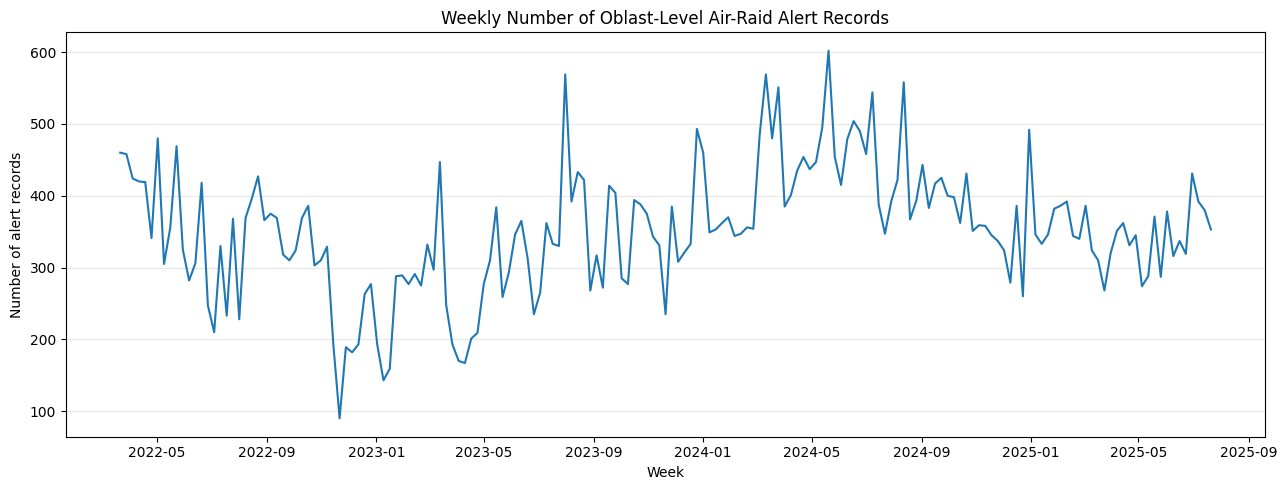

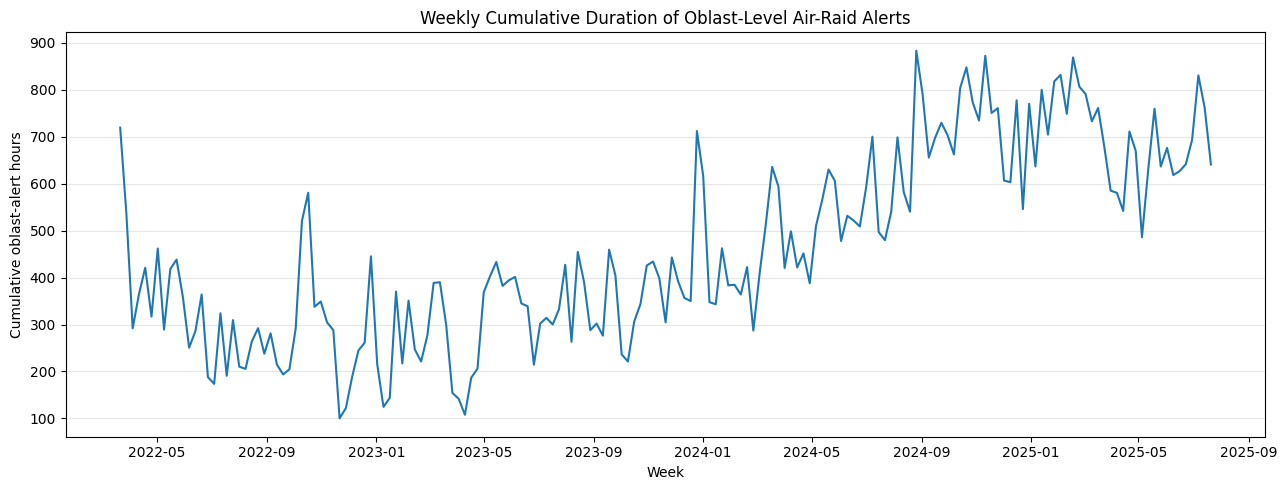


TOP TEN OBLASTS BY CUMULATIVE ALERT DURATION


,oblast,cumulative_alert_hours
4,Donetska oblast,10530.4
6,Kharkivska oblast,9058.3
18,Sumska oblast,7870.5
23,Zaporizka oblast,6568.7
3,Dnipropetrovska oblast,5253.1
16,Poltavska oblast,5224.1
1,Chernihivska oblast,4093.8
14,Mykolaivska oblast,3938.9
9,Kirovohradska oblast,3796.2
7,Khersonska oblast,3563.3


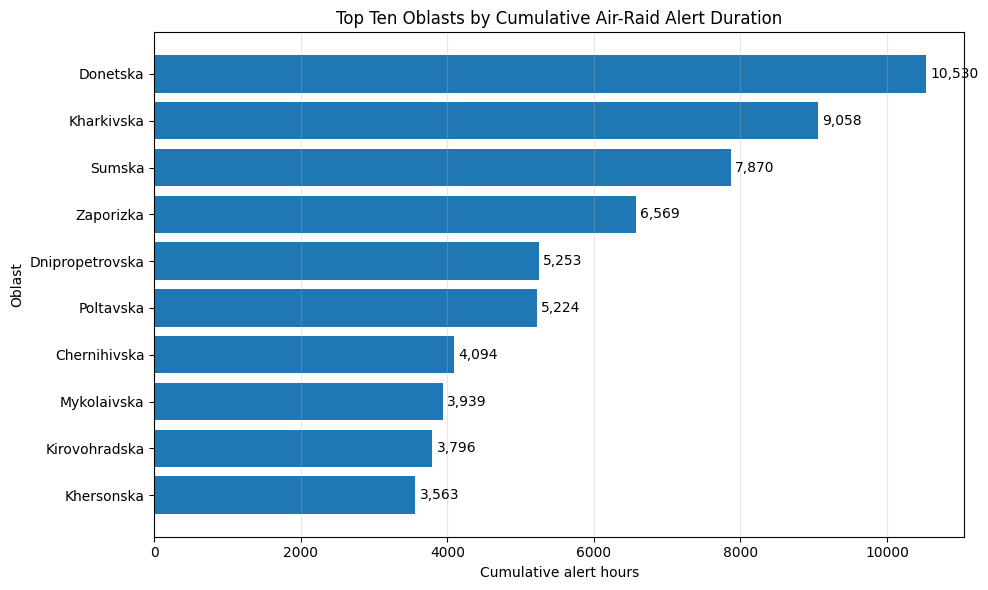


Saved PNG files:
1. weekly_oblast_alert_count.png
2. weekly_oblast_alert_hours.png
3. top10_oblasts_cumulative_alert_hours.png


In [5]:
# ============================================================
# FINAL RESULTS
# 1. Weekly oblast-level alert count
# 2. Weekly cumulative oblast-alert hours
# 3. Top ten oblasts by cumulative alert duration
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

required_weekly_columns = {
    "week_start",
    "alert_count",
    "alert_hours",
    "is_complete_week",
}

missing_weekly = required_weekly_columns - set(weekly_oblast.columns)

if missing_weekly:
    raise ValueError(
        f"weekly_oblast is missing columns: {sorted(missing_weekly)}"
    )

if "oblast" not in oblast_clean.columns or "duration_hours" not in oblast_clean.columns:
    raise ValueError(
        "oblast_clean must contain 'oblast' and 'duration_hours'."
    )

assert not weekly_oblast["week_start"].duplicated().any()
assert (weekly_oblast["alert_count"] >= 0).all()
assert (weekly_oblast["alert_hours"] >= 0).all()
assert (oblast_clean["duration_hours"] > 0).all()

# Use only complete calendar weeks for comparable weekly plots
weekly_complete = (
    weekly_oblast.loc[weekly_oblast["is_complete_week"]]
    .sort_values("week_start")
    .copy()
)

# Confirm that complete weeks form a continuous Monday sequence
expected_weeks = pd.date_range(
    weekly_complete["week_start"].min(),
    weekly_complete["week_start"].max(),
    freq="W-MON"
)

assert list(weekly_complete["week_start"]) == list(expected_weeks)

print(f"Complete weeks plotted: {len(weekly_complete):,}")
print(
    "Weekly plotting period:",
    weekly_complete["week_start"].min().date(),
    "to",
    weekly_complete["week_start"].max().date(),
)

# ------------------------------------------------------------
# Figure 1: weekly oblast-level alert count
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    weekly_complete["week_start"],
    weekly_complete["alert_count"],
    linewidth=1.5
)

ax.set_title("Weekly Number of Oblast-Level Air-Raid Alert Records")
ax.set_xlabel("Week")
ax.set_ylabel("Number of alert records")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(
    "weekly_oblast_alert_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Figure 2: weekly cumulative oblast-alert hours
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    weekly_complete["week_start"],
    weekly_complete["alert_hours"],
    linewidth=1.5
)

ax.set_title("Weekly Cumulative Duration of Oblast-Level Air-Raid Alerts")
ax.set_xlabel("Week")
ax.set_ylabel("Cumulative oblast-alert hours")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(
    "weekly_oblast_alert_hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Figure 3: top ten oblasts by cumulative alert duration
# ------------------------------------------------------------

oblast_burden = (
    oblast_clean
    .groupby("oblast", as_index=False)["duration_hours"]
    .sum()
    .rename(columns={"duration_hours": "cumulative_alert_hours"})
    .sort_values(
        "cumulative_alert_hours",
        ascending=False
    )
)

top10_oblasts = oblast_burden.head(10).copy()

# Shorten labels only for the figure
top10_oblasts["plot_label"] = (
    top10_oblasts["oblast"]
    .str.replace(" oblast", "", regex=False)
)

print("\nTOP TEN OBLASTS BY CUMULATIVE ALERT DURATION")
display(
    top10_oblasts[
        ["oblast", "cumulative_alert_hours"]
    ].round({"cumulative_alert_hours": 1})
)

# Ascending order places the largest bar at the top
plot_data = top10_oblasts.sort_values(
    "cumulative_alert_hours",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_data["plot_label"],
    plot_data["cumulative_alert_hours"]
)

ax.set_title("Top Ten Oblasts by Cumulative Air-Raid Alert Duration")
ax.set_xlabel("Cumulative alert hours")
ax.set_ylabel("Oblast")
ax.grid(axis="x", alpha=0.3)

ax.bar_label(
    bars,
    labels=[
        f"{value:,.0f}"
        for value in plot_data["cumulative_alert_hours"]
    ],
    padding=3
)

fig.tight_layout()
fig.savefig(
    "top10_oblasts_cumulative_alert_hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved PNG files:")
print("1. weekly_oblast_alert_count.png")
print("2. weekly_oblast_alert_hours.png")
print("3. top10_oblasts_cumulative_alert_hours.png")

#**Data cleaning and methodology**

At the time of analysis, the source file contained 273,584 rows. The audit identified 113,845 exact duplicate rows, which would have substantially inflated both alert frequency and cumulative duration.

Duplicates were removed when all seven original source fields were identical:

oblast
raion
hromada
level
started_at
finished_at
source

The first copy of each duplicated record was retained. Records with missing timestamps, missing oblast names, or non-positive durations were excluded.

The final analytical cohort contained 62,139 unique, valid oblast-level alert records. Alerts beginning on or after 1 August 2025 were excluded because reporting had shifted substantially toward the raion level.

Two weekly metrics were calculated:

Weekly alert frequency: the number of oblast-level alert records starting during each week.
Weekly cumulative oblast-alert hours: the total duration of alerts summed across oblasts.

Alerts crossing a weekly boundary were divided between the relevant weeks. Therefore, one hour of alert time in two oblasts contributes two cumulative oblast-alert hours. This metric does not represent unique national clock time.

The first and final partial calendar weeks were excluded from the weekly time-series figures. The oblast ranking used the full study interval through the 31 July 2025 cutoff.

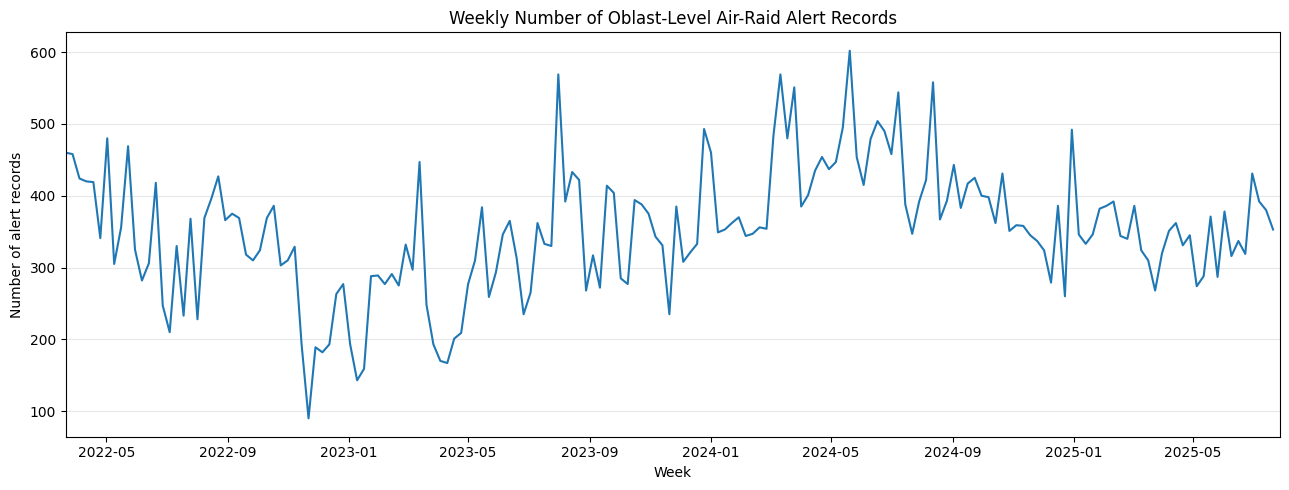

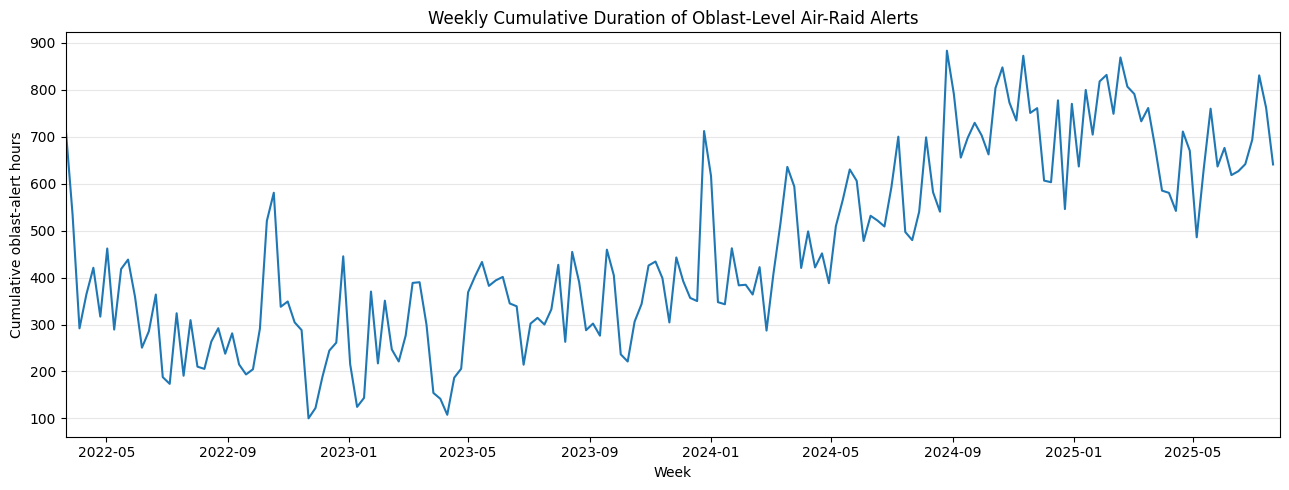

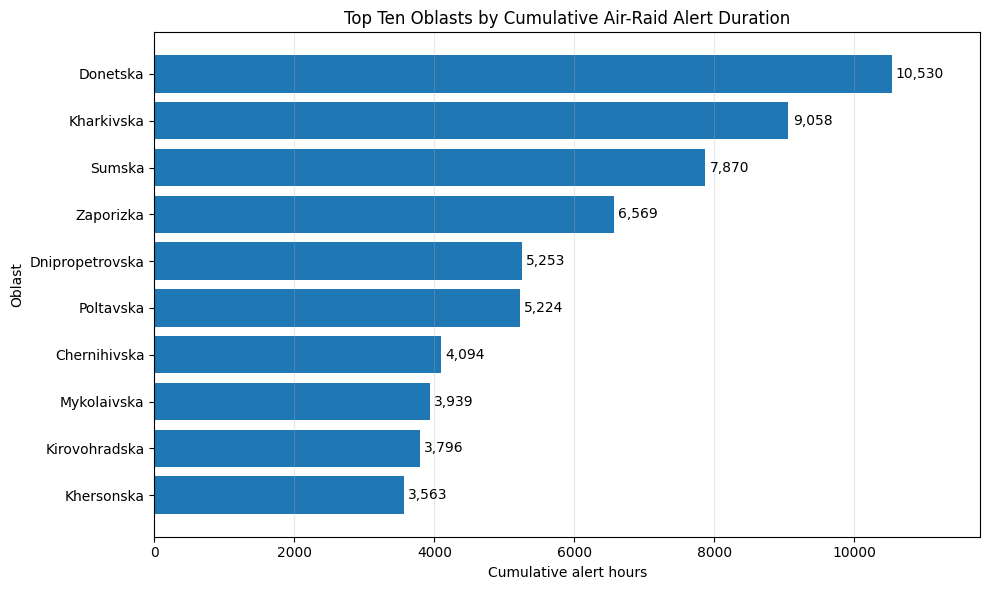


CREATED FILES
figures/weekly_oblast_alert_count.png                   309.7 KB
figures/weekly_oblast_alert_hours.png                   330.4 KB
figures/top10_oblasts_cumulative_alert_hours.png        169.6 KB
outputs/weekly_oblast_metrics.csv                       13.6 KB
outputs/oblast_cumulative_alert_hours.csv               983 B


In [6]:
# ============================================================
# SELF-CONTAINED FINAL EXPORT
# Recreates the cleaned cohort, weekly metrics, figures and CSVs
# ============================================================

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "Vadimkin/ukrainian-air-raid-sirens-dataset/"
    "main/datasets/official_data_en.csv"
)

LOCAL_TZ = "Europe/Kyiv"
ANALYSIS_CUTOFF = pd.Timestamp(
    "2025-08-01 00:00:00",
    tz=LOCAL_TZ
)

ORIGINAL_COLUMNS = [
    "oblast",
    "raion",
    "hromada",
    "level",
    "started_at",
    "finished_at",
    "source",
]

FIGURES_DIR = Path("figures")
OUTPUTS_DIR = Path("outputs")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Load and clean the source data
# ------------------------------------------------------------

df = pd.read_csv(DATA_URL, low_memory=False)

missing_columns = [
    column for column in ORIGINAL_COLUMNS
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

df["started_at"] = pd.to_datetime(
    df["started_at"],
    errors="coerce",
    utc=True
)

df["finished_at"] = pd.to_datetime(
    df["finished_at"],
    errors="coerce",
    utc=True
)

df["level"] = (
    df["level"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df["oblast"] = (
    df["oblast"]
    .astype("string")
    .str.strip()
)

# Retain the first copy of rows identical across all source fields
df_clean = (
    df
    .drop_duplicates(
        subset=ORIGINAL_COLUMNS,
        keep="first"
    )
    .copy()
)

df_clean["raw_duration_hours"] = (
    df_clean["finished_at"] - df_clean["started_at"]
).dt.total_seconds() / 3600


# ------------------------------------------------------------
# 3. Create the oblast-level analysis cohort
# ------------------------------------------------------------

oblast_clean = df_clean.loc[
    df_clean["level"].eq("oblast")
    & df_clean["oblast"].notna()
    & df_clean["started_at"].notna()
    & df_clean["finished_at"].notna()
    & df_clean["raw_duration_hours"].gt(0)
].copy()

oblast_clean["started_local"] = (
    oblast_clean["started_at"]
    .dt.tz_convert(LOCAL_TZ)
)

oblast_clean["finished_local"] = (
    oblast_clean["finished_at"]
    .dt.tz_convert(LOCAL_TZ)
)

oblast_clean = oblast_clean.loc[
    oblast_clean["started_local"] < ANALYSIS_CUTOFF
].copy()

# Clip any alert extending beyond the analysis cutoff
oblast_clean["analysis_finish_local"] = (
    oblast_clean["finished_local"]
    .where(
        oblast_clean["finished_local"] < ANALYSIS_CUTOFF,
        ANALYSIS_CUTOFF
    )
)

oblast_clean = oblast_clean.loc[
    oblast_clean["analysis_finish_local"]
    > oblast_clean["started_local"]
].copy()

oblast_clean["duration_hours"] = (
    oblast_clean["analysis_finish_local"]
    - oblast_clean["started_local"]
).dt.total_seconds() / 3600

# Monday containing the alert start
oblast_clean["start_week"] = (
    oblast_clean["started_local"].dt.normalize()
    - pd.to_timedelta(
        oblast_clean["started_local"].dt.weekday,
        unit="D"
    )
)

oblast_clean = (
    oblast_clean
    .sort_values(["started_local", "oblast"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Weekly alert frequency
# ------------------------------------------------------------

weekly_frequency = (
    oblast_clean
    .groupby("start_week")
    .size()
    .rename("alert_count")
)


# ------------------------------------------------------------
# 5. Weekly cumulative duration
# Split alerts across Monday-based weekly boundaries
# ------------------------------------------------------------

duration_segments = []

for alert in oblast_clean.itertuples(index=False):

    segment_start = alert.started_local
    alert_end = alert.analysis_finish_local

    while segment_start < alert_end:

        week_start = (
            segment_start.normalize()
            - pd.Timedelta(days=segment_start.weekday())
        )

        next_week_start = week_start + pd.DateOffset(weeks=1)
        segment_end = min(alert_end, next_week_start)

        segment_hours = (
            segment_end - segment_start
        ).total_seconds() / 3600

        duration_segments.append(
            {
                "week_start": week_start,
                "alert_hours": segment_hours,
            }
        )

        segment_start = segment_end

duration_segments = pd.DataFrame(duration_segments)

weekly_duration = (
    duration_segments
    .groupby("week_start")["alert_hours"]
    .sum()
)


# ------------------------------------------------------------
# 6. Create the continuous weekly table
# ------------------------------------------------------------

first_week = min(
    weekly_frequency.index.min(),
    weekly_duration.index.min()
)

last_included_time = (
    ANALYSIS_CUTOFF - pd.Timedelta(nanoseconds=1)
)

last_week = (
    last_included_time.normalize()
    - pd.Timedelta(days=last_included_time.weekday())
)

complete_week_index = pd.date_range(
    start=first_week,
    end=last_week,
    freq="W-MON"
)

weekly_oblast = (
    pd.concat(
        [weekly_frequency, weekly_duration],
        axis=1
    )
    .reindex(complete_week_index, fill_value=0)
    .rename_axis("week_start")
    .reset_index()
)

weekly_oblast["week_end"] = (
    weekly_oblast["week_start"]
    + pd.DateOffset(weeks=1)
)

analysis_start = oblast_clean["started_local"].min()

weekly_oblast["is_complete_week"] = (
    weekly_oblast["week_start"].ge(analysis_start)
    & weekly_oblast["week_end"].le(ANALYSIS_CUTOFF)
)

weekly_oblast["alert_count"] = (
    weekly_oblast["alert_count"].astype(int)
)

weekly_complete = (
    weekly_oblast.loc[
        weekly_oblast["is_complete_week"]
    ]
    .sort_values("week_start")
    .copy()
)

first_complete_week_start = (
    weekly_complete["week_start"].min()
)

final_complete_week_end = (
    weekly_complete["week_end"].max()
)


# ------------------------------------------------------------
# 7. Full oblast ranking
# ------------------------------------------------------------

oblast_ranking = (
    oblast_clean
    .groupby("oblast", as_index=False)["duration_hours"]
    .sum()
    .rename(
        columns={
            "duration_hours": "cumulative_alert_hours"
        }
    )
    .sort_values(
        "cumulative_alert_hours",
        ascending=False
    )
    .reset_index(drop=True)
)

oblast_ranking.insert(
    0,
    "rank",
    range(1, len(oblast_ranking) + 1)
)

top10_oblasts = oblast_ranking.head(10).copy()

top10_oblasts["plot_label"] = (
    top10_oblasts["oblast"]
    .str.replace(" oblast", "", regex=False)
)


# ------------------------------------------------------------
# 8. Export tables
# ------------------------------------------------------------

weekly_oblast.to_csv(
    OUTPUTS_DIR / "weekly_oblast_metrics.csv",
    index=False
)

oblast_ranking.to_csv(
    OUTPUTS_DIR / "oblast_cumulative_alert_hours.csv",
    index=False
)


# ------------------------------------------------------------
# 9. Figure: weekly alert count
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    weekly_complete["week_start"],
    weekly_complete["alert_count"],
    linewidth=1.5
)

ax.set_xlim(
    first_complete_week_start,
    final_complete_week_end
)

ax.set_title(
    "Weekly Number of Oblast-Level Air-Raid Alert Records"
)
ax.set_xlabel("Week")
ax.set_ylabel("Number of alert records")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "weekly_oblast_alert_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 10. Figure: weekly cumulative alert hours
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    weekly_complete["week_start"],
    weekly_complete["alert_hours"],
    linewidth=1.5
)

ax.set_xlim(
    first_complete_week_start,
    final_complete_week_end
)

ax.set_title(
    "Weekly Cumulative Duration of Oblast-Level Air-Raid Alerts"
)
ax.set_xlabel("Week")
ax.set_ylabel("Cumulative oblast-alert hours")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "weekly_oblast_alert_hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 11. Figure: top ten oblasts
# ------------------------------------------------------------

plot_data = top10_oblasts.sort_values(
    "cumulative_alert_hours",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_data["plot_label"],
    plot_data["cumulative_alert_hours"]
)

maximum_hours = (
    plot_data["cumulative_alert_hours"].max()
)

ax.set_xlim(0, maximum_hours * 1.12)

ax.set_title(
    "Top Ten Oblasts by Cumulative Air-Raid Alert Duration"
)
ax.set_xlabel("Cumulative alert hours")
ax.set_ylabel("Oblast")
ax.grid(axis="x", alpha=0.3)

ax.bar_label(
    bars,
    labels=[
        f"{value:,.0f}"
        for value in plot_data["cumulative_alert_hours"]
    ],
    padding=3
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "top10_oblasts_cumulative_alert_hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 12. Display created files and sizes
# ------------------------------------------------------------

created_files = [
    FIGURES_DIR / "weekly_oblast_alert_count.png",
    FIGURES_DIR / "weekly_oblast_alert_hours.png",
    FIGURES_DIR / "top10_oblasts_cumulative_alert_hours.png",
    OUTPUTS_DIR / "weekly_oblast_metrics.csv",
    OUTPUTS_DIR / "oblast_cumulative_alert_hours.csv",
]

def format_file_size(size_bytes):
    if size_bytes < 1024:
        return f"{size_bytes} B"
    if size_bytes < 1024**2:
        return f"{size_bytes / 1024:.1f} KB"
    return f"{size_bytes / 1024**2:.2f} MB"


print("\nCREATED FILES")

for file_path in created_files:
    print(
        f"{file_path.as_posix():55s} "
        f"{format_file_size(file_path.stat().st_size)}"
    )

#**Main findings**

Weekly oblast-level alert frequency was highly variable throughout the study period. Complete-week counts ranged from approximately 90 to 600 records, without a single continuous upward or downward trend.

A pronounced lower-frequency period was visible around late 2022 and early 2023. Alert frequency subsequently recovered, with several of the largest weekly peaks occurring during early and mid-2024.

Weekly cumulative oblast-alert duration showed a clearer long-term change. During much of 2022 and 2023, cumulative duration commonly remained between approximately 200 and 450 oblast-alert hours per week. From around mid-2024 through July 2025, it was more persistently elevated, frequently reaching approximately 550–850 oblast-alert hours.

Cumulative oblast-alert hours remained elevated during periods when weekly alert counts were not at their maximum. This divergence shows that alert frequency and total duration capture different aspects of alert burden, but it does not demonstrate an increase in mean alert duration.

Donetska oblast had the greatest recorded cumulative alert duration, with approximately 10,530 hours. It was followed by Kharkivska oblast with 9,058 hours and Sumska oblast with 7,870 hours. Zaporizka and Dnipropetrovska oblasts completed the top five.

**Limitations**

The analysis includes only oblast-level records from 15 March 2022 through 31 July 2025. Later observations were excluded because the source data shifted substantially toward raion-level reporting.

The results describe recorded official alert declarations. They should not be interpreted as direct measures of attacks, casualties, military activity, or objective regional danger.

Recorded alert patterns may also be influenced by changes in reporting systems, regional alert policies, administrative decisions, and official threat-assessment practices.

Alert frequency and cumulative duration are complementary but not interchangeable. Frequency gives equal weight to every alert record, while cumulative hours give greater weight to longer alerts.

The weekly figures exclude the first and final partial calendar weeks. The regional cumulative ranking uses the complete available study interval through the cutoff.

In [7]:
!zip -r air_raid_analysis_results.zip figures outputs

  adding: figures/ (stored 0%)
  adding: figures/weekly_oblast_alert_count.png (deflated 8%)
  adding: figures/weekly_oblast_alert_hours.png (deflated 8%)
  adding: figures/top10_oblasts_cumulative_alert_hours.png (deflated 25%)
  adding: outputs/ (stored 0%)
  adding: outputs/oblast_cumulative_alert_hours.csv (deflated 55%)
  adding: outputs/weekly_oblast_metrics.csv (deflated 81%)


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
